In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, entropy
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone  # Added missing import
import shap
from tqdm import tqdm
from sklearn.metrics import r2_score  # Added for completeness


/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
import pandas as pd
df = pd.read_csv("datasets/parkinsons.csv")

df.head()

df.drop("name", axis =1, inplace = True)

In [3]:
df.shape

(195, 23)

In [4]:
df.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [5]:
df.status.unique

<bound method Series.unique of 0      1
1      1
2      1
3      1
4      1
      ..
190    0
191    0
192    0
193    0
194    0
Name: status, Length: 195, dtype: int64>

In [6]:
# Load dataset and train model

X = df.drop("status", axis = 1)
y = df["status"]
feature_names = X.columns
print(feature_names)

Index(['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1',
       'spread2', 'D2', 'PPE'],
      dtype='object')


In [7]:
import shap

In [8]:
import sys
sys.path.append("../")

In [9]:
from QUEST import QUESTExplainerRegressor

/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but De


Feature Impact Summary with Uncertainty Quantification:
- MDVP:Fo(Hz): -0.0671 ± 0.0881 (95% CI: [-0.3215, 0.0285], Sign Stability: 85.20%)
- MDVP:Fhi(Hz): -0.0727 ± 0.0675 (95% CI: [-0.2314, 0.0000], Sign Stability: 92.40%)
- MDVP:Flo(Hz): -0.0145 ± 0.0538 (95% CI: [-0.1732, 0.0513], Sign Stability: 58.00%)
- MDVP:Jitter(%): -0.0028 ± 0.0263 (95% CI: [-0.0542, 0.0174], Sign Stability: 23.60%)
- MDVP:Jitter(Abs): 0.0015 ± 0.0045 (95% CI: [-0.0001, 0.0170], Sign Stability: 33.20%)
- MDVP:RAP: -0.0027 ± 0.0106 (95% CI: [-0.0315, 0.0069], Sign Stability: 36.60%)
- MDVP:PPQ: -0.0002 ± 0.0097 (95% CI: [-0.0219, 0.0177], Sign Stability: 35.80%)
- Jitter:DDP: 0.0004 ± 0.0066 (95% CI: [-0.0077, 0.0126], Sign Stability: 24.60%)
- MDVP:Shimmer: -0.0006 ± 0.0156 (95% CI: [-0.0407, 0.0384], Sign Stability: 35.80%)
- MDVP:Shimmer(dB): -0.0029 ± 0.0114 (95% CI: [-0.0351, 0.0188], Sign Stability: 50.40%)
- Shimmer:APQ3: -0.0024 ± 0.0131 (95% CI: [-0.0388, 0.0221], Sign Stability: 38.00%)
- Shimmer:A

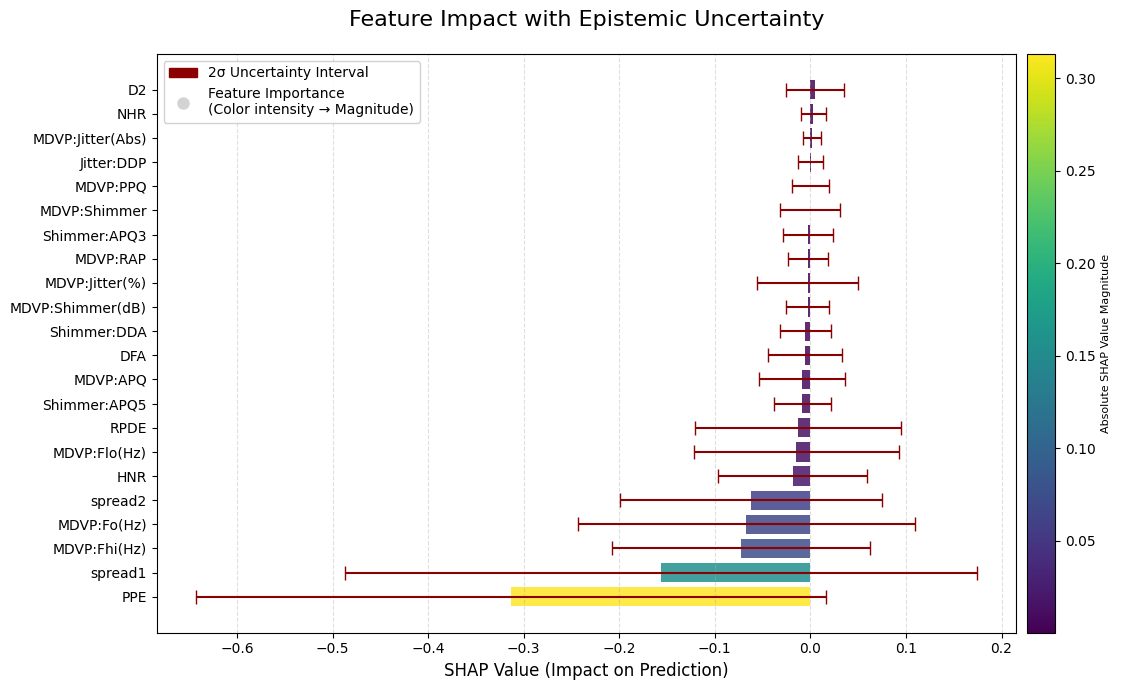

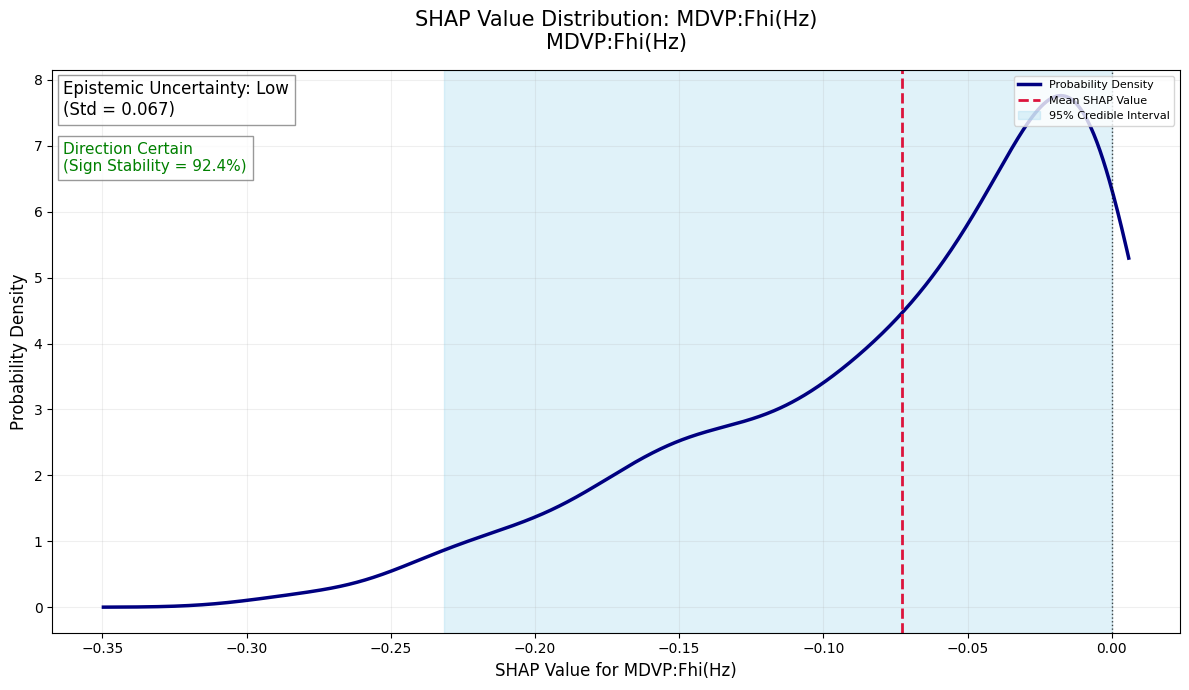

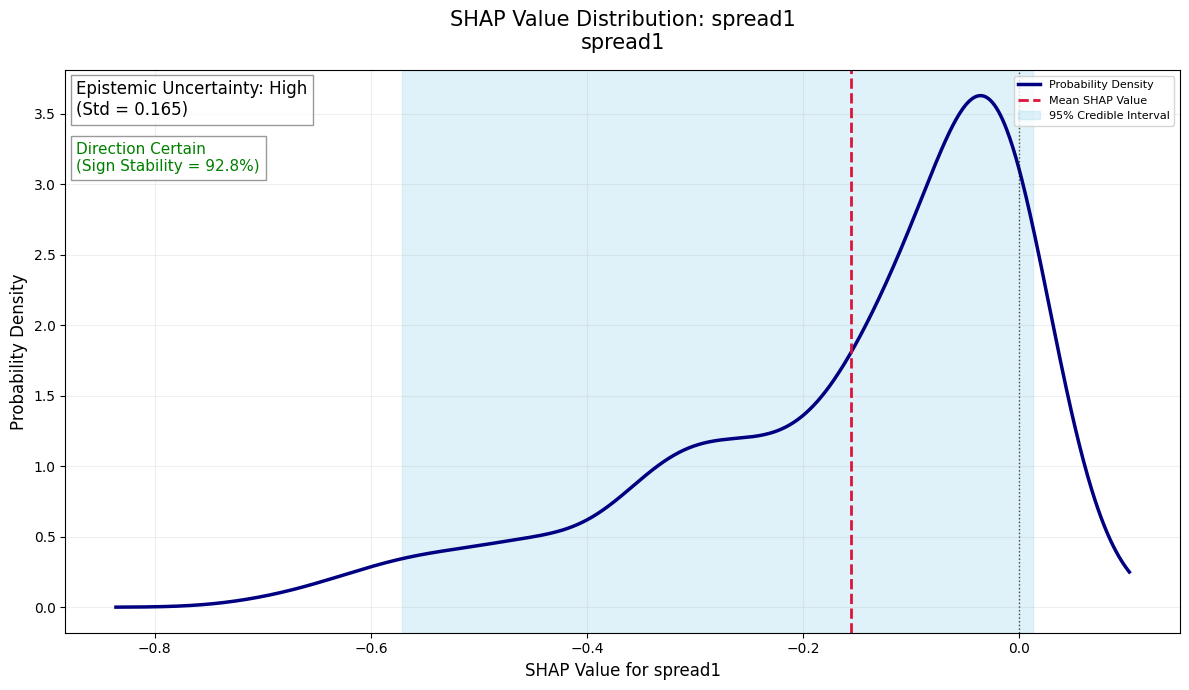

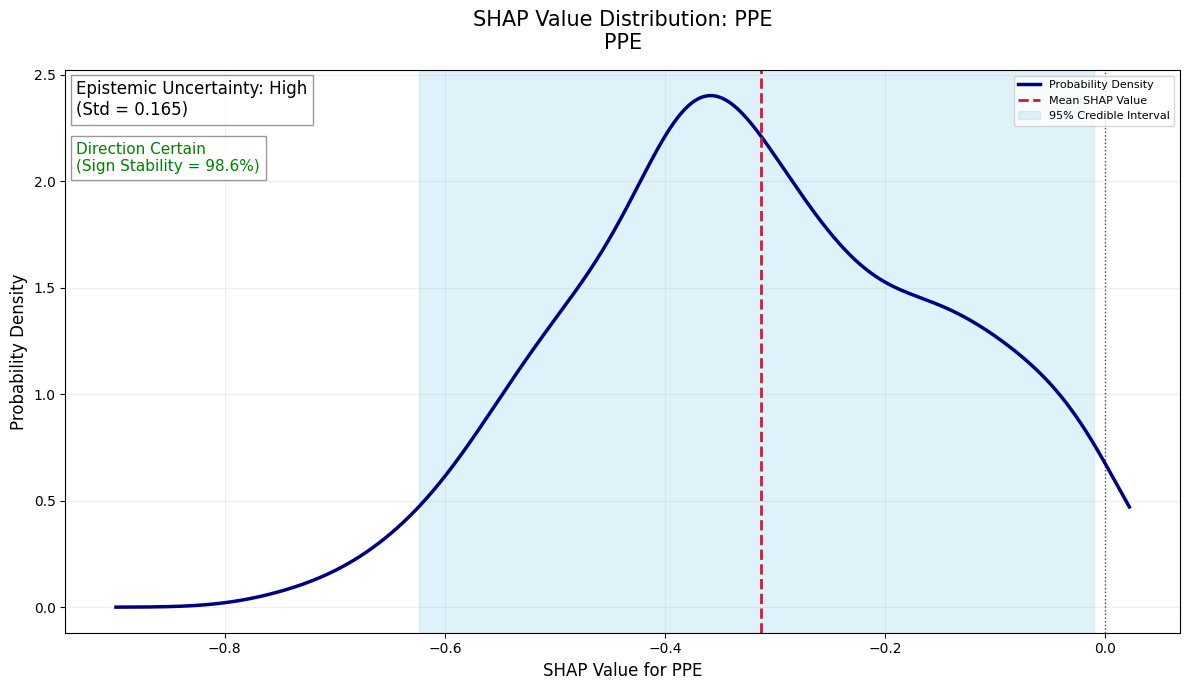

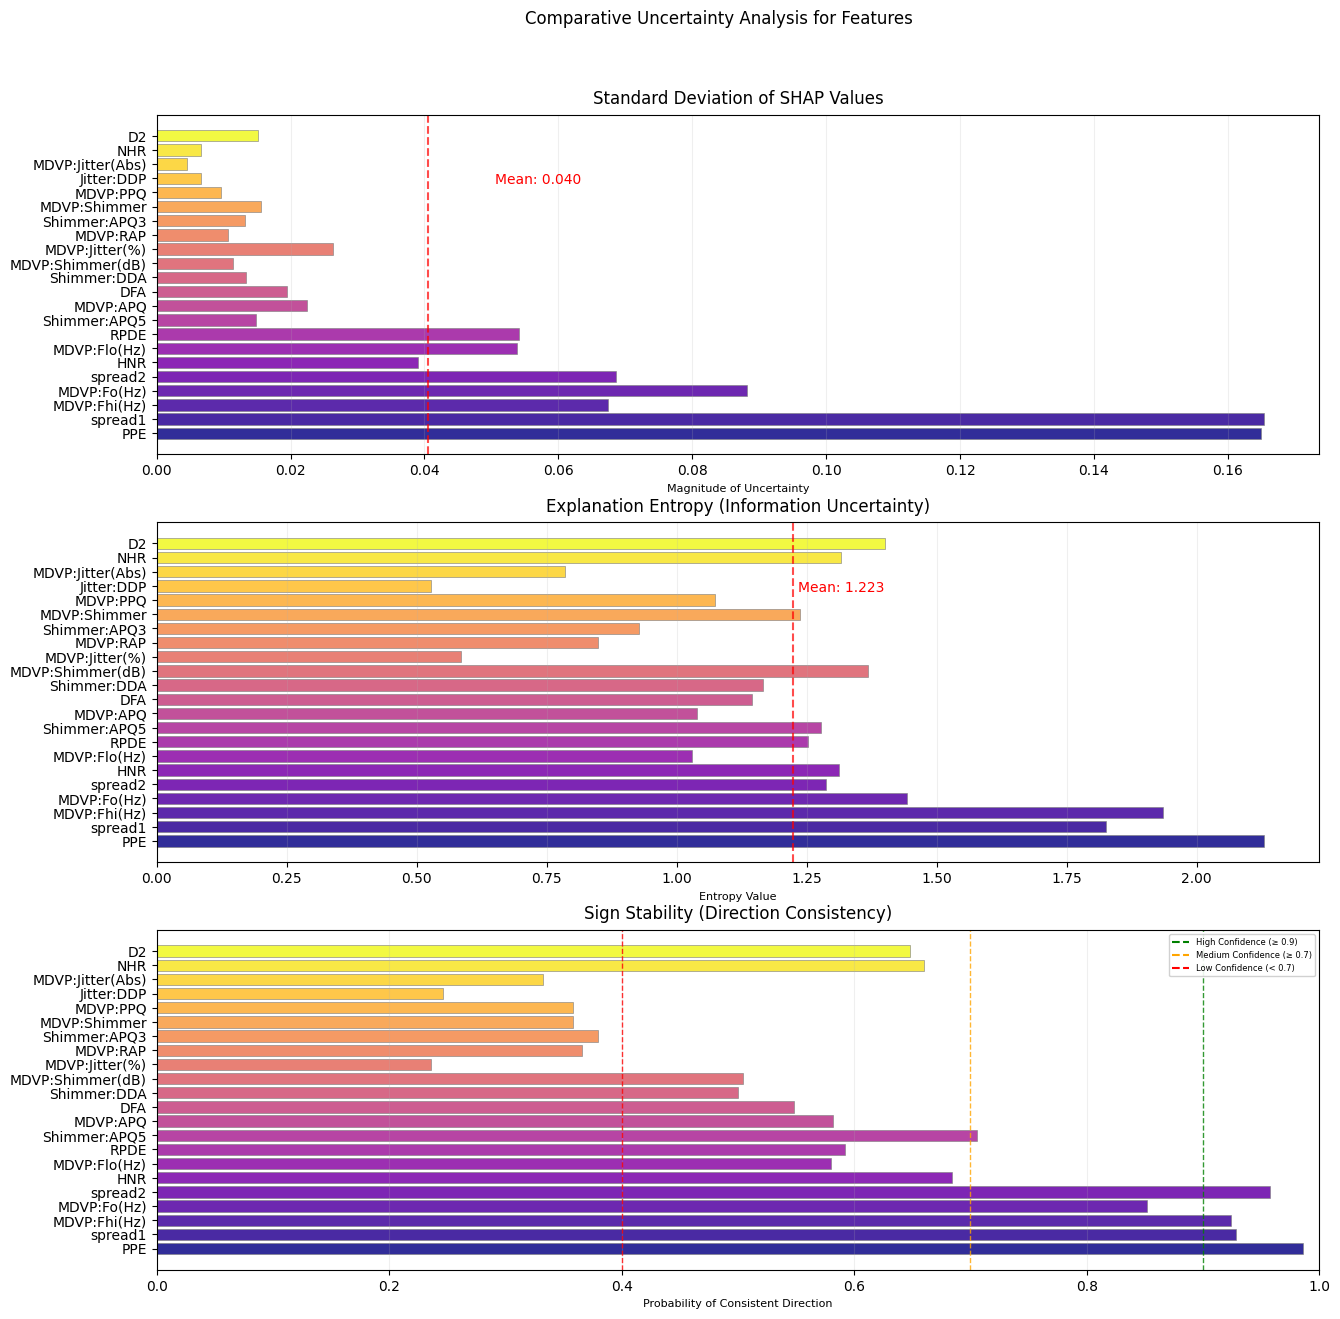

In [ ]:


model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Initialize E-SHAP explainer
quest = QUESTExplainerRegressor(model, X, y, beta=5.0, random_state=42)

# Explain an instance
instance = X[42:43]  # Select an interesting instance
result = quest.explain(instance, n_samples=500)

print("\n" + "="*80)
print("Feature Impact Summary with Uncertainty Quantification:")
for i, name in enumerate(feature_names):
    print(f"- {name}: {result['mean'][i]:.4f} ± {result['std'][i]:.4f} "
            f"(95% CI: [{result['ci_95'][0][i]:.4f}, {result['ci_95'][1][i]:.4f}], "
            f"Sign Stability: {result['sign_stability'][i]:.2%})")
print("="*80 + "\n")

# Visualizations
quest.plot_uncertainty_bars(result, feature_names, 
                            "Feature Impact with Epistemic Uncertainty")

# Plot distributions for top 3 features
top_features = np.argsort(np.abs(result['mean']))[-3:]
for idx in top_features:
    quest.plot_uncertainty_distribution(result, feature_names, idx, 
                                        f"SHAP Value Distribution: {feature_names[idx]}")

# eshap.plot_uncertainty_heatmap(result, feature_names, 
#                                 "SHAP Uncertainty Metrics for Features")

quest.plot_uncertainty_comparison(result, feature_names, 
                                "Comparative Uncertainty Analysis for Features")